# 02 - Features: what signals future customer value?

Built by `scripts/build_features.py` from `src/cvo_demo/features.py`. Each row = one customer at one **snapshot date**:
features use data *before* that date, the target is spend in the *next 90 days*.

Feature families (classic RFM plus a few CVO-flavoured extras):
- **Recency / tenure:** `recency_days`, `tenure_days`
- **Frequency:** `frequency`, `orders_30d/90d/180d`, `orders_per_month`, `avg_gap_days`
- **Monetary:** `monetary_total`, `avg_order_value`, `spend_30d/90d/180d`, `max/std_order_value`
- **Momentum:** `spend_trend_90_vs_prior`, `overdue_ratio` (days since last order / usual gap; >1 means "late", a churn signal)
- **Breadth and quality:** `n_unique_products`, `return_rate`, `return_value_share`, `is_uk`

In [5]:
import json, pandas as pd, numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.width", 140); pd.set_option("display.max_columns", 40)

ds = pd.read_parquet("../data/processed/features.parquet")
meta = json.load(open("../data/processed/feature_meta.json"))
FEATS, TARGET = meta["feature_columns"], meta["target"]
print(meta)
ds.groupby(["split", "snapshot_date"]).agg(customers=("customer_id", "size"),
    buy_rate=("target_will_buy", "mean"), mean_spend=(TARGET, "mean"), median_spend=(TARGET, "median")).round(2)

{'feature_columns': ['recency_days', 'tenure_days', 'frequency', 'monetary_total', 'avg_order_value', 'max_order_value', 'std_order_value', 'items_total', 'avg_gap_days', 'overdue_ratio', 'orders_per_month', 'n_unique_products', 'orders_30d', 'orders_90d', 'orders_180d', 'spend_30d', 'spend_90d', 'spend_180d', 'spend_trend_90_vs_prior', 'return_rate', 'return_value_share', 'is_uk'], 'target': 'target_spend_90d', 'horizon_days': 90, 'train_cutoffs': ['2010-09-14', '2010-12-13', '2011-03-13', '2011-06-11'], 'test_cutoff': '2011-09-09', 'serving_as_of': '2011-12-10'}


customers  buy_rate  mean_spend  median_spend
split snapshot_date                                               
test  2011-09-09          5278      0.43      539.20           0.0
train 2010-09-14          3386      0.57      826.96         213.4
      2010-12-13          4319      0.30      299.56           0.0
      2011-03-13          4606      0.35      338.17           0.0
      2011-06-11          4976      0.32      336.65           0.0

In [9]:
ds.head(5)

,customer_id,snapshot_date,recency_days,tenure_days,frequency,monetary_total,avg_order_value,max_order_value,std_order_value,items_total,avg_gap_days,overdue_ratio,orders_per_month,n_unique_products,orders_30d,orders_90d,orders_180d,spend_30d,spend_90d,spend_180d,spend_trend_90_vs_prior,return_rate,return_value_share,is_uk,target_spend_90d,target_will_buy,split
0,12346,2010-09-14,77.421528,273.643056,11.0,372.86,33.896364,142.31,37.302802,70.0,19.622153,3.945618,1.205951,26.0,0.0,1.0,1.0,0.0,142.31,142.31,142.310000,0.153846,0.536762,1.0,0.00,0,train
1,12349,2010-09-14,118.585417,137.444444,2.0,1268.52,634.260000,1068.52,614.136382,474.0,18.859028,6.287992,0.436540,47.0,0.0,0.0,2.0,0.0,0.00,1268.52,-0.999212,0.333333,0.018682,0.0,1402.62,1,train
2,12355,2010-09-14,115.500694,115.500694,1.0,488.21,488.210000,488.21,0.000000,303.0,NaN,NaN,0.259739,22.0,0.0,0.0,1.0,0.0,0.00,488.21,-0.997956,0.000000,0.000000,0.0,0.00,0,train
3,12358,2010-09-14,98.480556,279.667361,2.0,1697.93,848.965000,1429.83,821.467161,590.0,181.186806,0.543531,0.214541,34.0,0.0,0.0,1.0,0.0,0.00,268.10,-0.996284,0.000000,0.000000,0.0,1021.08,1,train
4,12359,2010-09-14,83.566667,282.436111,5.0,2012.03,402.406000,760.69,249.260546,877.0,49.717361,1.680835,0.531094,82.0,0.0,1.0,2.0,0.0,489.80,835.40,0.416042,0.285714,0.044634,0.0,551.33,1,train


## 1. Is the setup stable across snapshots?
Buy rate and spend should be in the same ballpark across train and test snapshots. A big shift (for example November
peak season in one window) would explain surprises in step 3.

In [3]:
ds[FEATS].describe().T[["count", "mean", "50%", "max"]].round(2)

,count,mean,50%,max
recency_days,22565.0,147.39,104.47,646.59
tenure_days,22565.0,313.99,304.35,646.68
frequency,22565.0,4.91,2.00,309.00
monetary_total,22565.0,2315.65,732.94,484615.10
avg_order_value,22565.0,381.49,290.02,14844.77
max_order_value,22565.0,643.00,380.28,77183.60
std_order_value,22565.0,154.63,70.24,22271.23
items_total,22565.0,1434.62,403.00,298022.00
avg_gap_days,15228.0,77.19,57.34,632.12
overdue_ratio,15228.0,2032.62,1.05,831440.00


## 2. Which features carry signal? (Spearman rank correlation with next-90-day spend, train only)

,recency_days,avg_gap_days,overdue_ratio,is_uk,spend_trend_90_vs_prior,tenure_days,return_rate,return_value_share,avg_order_value,orders_30d,spend_30d,max_order_value,std_order_value,n_unique_products,orders_90d,spend_90d,orders_per_month,items_total,frequency,monetary_total,orders_180d,spend_180d
spearman,-0.389,-0.27,-0.166,-0.038,0.026,0.082,0.198,0.216,0.241,0.315,0.324,0.346,0.352,0.36,0.411,0.42,0.433,0.441,0.445,0.453,0.466,0.476


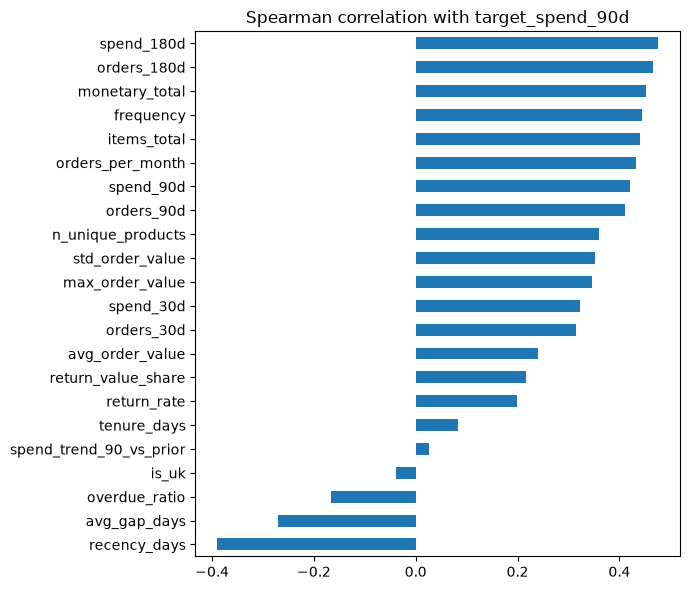

In [4]:
tr = ds[ds.split == "train"]
corr = tr[FEATS].corrwith(tr[TARGET], method="spearman").sort_values()
corr.plot.barh(figsize=(7, 6), title="Spearman correlation with target_spend_90d")
plt.tight_layout(); corr.round(3).to_frame("spearman").T

## 3. Recency is the classic one: buy probability by recency bucket

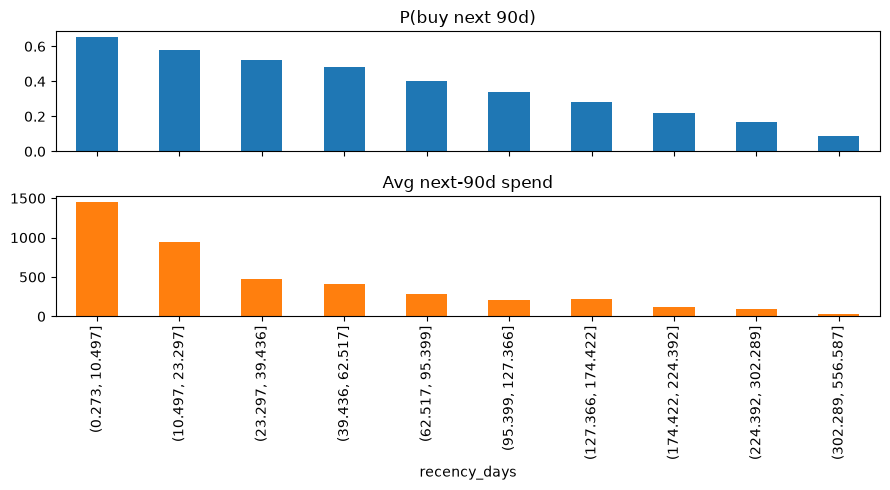

In [6]:
b = pd.qcut(tr.recency_days, 10, duplicates="drop")
r = tr.groupby(b, observed=True).agg(buy_rate=("target_will_buy", "mean"), avg_spend=(TARGET, "mean"))
r.plot(subplots=True, figsize=(9, 5), kind="bar", legend=False, title=["P(buy next 90d)", "Avg next-90d spend"])
plt.tight_layout()

## 4. Overdue ratio: are customers who are 'late vs. their own rhythm' less likely to return?

In [7]:
o = tr.dropna(subset=["overdue_ratio"])
b = pd.cut(o.overdue_ratio, [0, .5, 1, 1.5, 2, 3, np.inf])
o.groupby(b, observed=True).target_will_buy.agg(["mean", "size"]).round(2)

,mean,size
overdue_ratio,,
"(0.0, 0.5]",0.53,3591
"(0.5, 1.0]",0.55,2212
"(1.0, 1.5]",0.52,1354
"(1.5, 2.0]",0.51,885
"(2.0, 3.0]",0.45,1057
"(3.0, inf]",0.28,2428


## 5. Leakage sanity checks
1. `tests/test_features.py::test_no_future_leakage` corrupts all post-cutoff rows and asserts features do not change.
2. Train target windows end on or before the test cutoff (see the cutoffs above), so the test period was never seen in training.
3. Below: no single feature should be *almost perfectly* correlated with the target. If one is, suspect leakage.

In [8]:
print("Max |Spearman| with target:", corr.abs().max().round(3), "->", corr.abs().idxmax())
print("Missing values:"); ds[FEATS].isna().mean().round(3)[lambda s: s > 0]

Max |Spearman| with target: 0.476 -> spend_180d
Missing values:


avg_gap_days     0.325
overdue_ratio    0.325
dtype: float64

## 6. Notes for step 3 (modelling)
- Target is zero-inflated and heavy-tailed -> model `log1p(target)`, report MAE/RMSE on both scales, plus Spearman and top-decile lift.
- Baselines to beat: (a) predict spend in the last 90 days (`spend_90d`), (b) predict the train mean.
- `avg_gap_days` / `overdue_ratio` are NaN for one-time buyers: tree models handle it, linear baselines need imputation.
- Validate with the time split (`split` column), never a random split across snapshots.